# 📊 Dataset Information

**Note:** The dataset for this project is **not included in this repository** to keep the repository lightweight.  

You can download the dataset from **Kaggle** using the link below:  

[Download The Chess Rating Dataset](https://www.kaggle.com/datasets/sergionefedov/chess-rating-plateau-why-players-get-stuck?select=chess_rating_plateau.csv)  

Please make sure to place the downloaded CSV file in the same directory as this notebook before running any code.

# Importing

## Import Library

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report, ConfusionMatrixDisplay

## Import CSV And convert to DataFrame

In [2]:
df = pd.read_csv('chess_rating_plateau.csv')

# Preprocessing

## Frist five row

In [3]:
df.head()

,player_id,cognitive_ability,starting_age,age_now,years_playing,total_study_hours,deliberate_share,deliberate_hours,tactics_training_hours,analyzes_own_games,opening_study_hours,games_played,has_coach,studies_endgames,peak_rating,plateaued,reached_expert
0,CHS000000,3.95,14,20,6,4640,0.213,990,440,7.50,1760,470,0,1,866,0,0
1,CHS000001,4.64,31,47,16,510,0.386,200,100,7.61,200,760,1,1,747,0,0
2,CHS000002,2.13,15,20,5,990,0.212,210,50,7.40,450,9200,0,1,1484,1,0
3,CHS000003,6.27,14,26,12,1810,0.625,1130,450,9.20,450,2240,0,1,2280,0,1
4,CHS000004,7.70,8,19,11,3590,0.286,1030,490,5.69,1710,3200,0,1,2484,0,1


## last Five row

In [4]:
df.tail()

,player_id,cognitive_ability,starting_age,age_now,years_playing,total_study_hours,deliberate_share,deliberate_hours,tactics_training_hours,analyzes_own_games,opening_study_hours,games_played,has_coach,studies_endgames,peak_rating,plateaued,reached_expert
44995,CHS044995,2.64,16,21,5,320,0.077,20,10,6.56,140,660,0,1,400,1,0
44996,CHS044996,4.04,9,12,3,240,0.571,140,60,4.60,50,5080,1,0,1896,0,0
44997,CHS044997,3.93,11,14,3,750,0.406,300,160,7.56,280,3410,0,0,1575,1,0
44998,CHS044998,8.07,16,27,11,2870,0.295,850,380,7.11,1370,2700,0,0,2329,0,1
44999,CHS044999,4.36,23,31,8,1420,0.330,470,240,2.86,370,2440,0,1,1229,0,0


## Shape of our dataset

In [5]:
df.shape

(45000, 17)

## List out all columns

In [6]:
df.columns

Index(['player_id', 'cognitive_ability', 'starting_age', 'age_now',
       'years_playing', 'total_study_hours', 'deliberate_share',
       'deliberate_hours', 'tactics_training_hours', 'analyzes_own_games',
       'opening_study_hours', 'games_played', 'has_coach', 'studies_endgames',
       'peak_rating', 'plateaued', 'reached_expert'],
      dtype='object')

## Datatype of each columns

In [7]:
df.dtypes

player_id                  object
cognitive_ability         float64
starting_age                int64
age_now                     int64
years_playing               int64
total_study_hours           int64
deliberate_share          float64
deliberate_hours            int64
tactics_training_hours      int64
analyzes_own_games        float64
opening_study_hours         int64
games_played                int64
has_coach                   int64
studies_endgames            int64
peak_rating                 int64
plateaued                   int64
reached_expert              int64
dtype: object

## Information of all Columns

In [8]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 45000 entries, 0 to 44999
Data columns (total 17 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   player_id               45000 non-null  object 
 1   cognitive_ability       45000 non-null  float64
 2   starting_age            45000 non-null  int64  
 3   age_now                 45000 non-null  int64  
 4   years_playing           45000 non-null  int64  
 5   total_study_hours       45000 non-null  int64  
 6   deliberate_share        45000 non-null  float64
 7   deliberate_hours        45000 non-null  int64  
 8   tactics_training_hours  45000 non-null  int64  
 9   analyzes_own_games      45000 non-null  float64
 10  opening_study_hours     45000 non-null  int64  
 11  games_played            45000 non-null  int64  
 12  has_coach               45000 non-null  int64  
 13  studies_endgames        45000 non-null  int64  
 14  peak_rating             45000 non-null

## Check Null Value

In [9]:
df.isnull().sum()

player_id                 0
cognitive_ability         0
starting_age              0
age_now                   0
years_playing             0
total_study_hours         0
deliberate_share          0
deliberate_hours          0
tactics_training_hours    0
analyzes_own_games        0
opening_study_hours       0
games_played              0
has_coach                 0
studies_endgames          0
peak_rating               0
plateaued                 0
reached_expert            0
dtype: int64

## Check Dupicate Value

In [10]:
df.duplicated().sum()

np.int64(0)

## Summary

In [11]:
df.describe()

,cognitive_ability,starting_age,age_now,years_playing,total_study_hours,deliberate_share,deliberate_hours,tactics_training_hours,analyzes_own_games,opening_study_hours,games_played,has_coach,studies_endgames,peak_rating,plateaued,reached_expert
count,45000.000000,45000.000000,45000.000000,45000.000000,45000.000000,45000.000000,45000.000000,45000.000000,45000.000000,45000.000000,45000.000000,45000.000000,45000.000000,45000.000000,45000.000000,45000.000000
mean,5.013893,18.135578,30.256533,12.120956,1444.538667,0.399781,577.116667,231.187111,5.778695,434.358444,2691.650222,0.218711,0.351822,1521.426289,0.388333,0.200022
std,1.975675,8.829030,12.231597,8.488710,1144.544519,0.200349,586.645578,253.955170,2.242872,414.772396,1996.113570,0.413377,0.477544,550.254863,0.487376,0.400021
min,0.000000,5.000000,7.000000,1.000000,20.000000,0.020000,0.000000,0.000000,0.000000,0.000000,20.000000,0.000000,0.000000,400.000000,0.000000,0.000000
25%,3.670000,12.000000,21.000000,6.000000,610.000000,0.243000,180.000000,70.000000,4.230000,150.000000,1230.000000,0.000000,0.000000,1140.000000,0.000000,0.000000
50%,5.030000,16.000000,28.000000,10.000000,1160.000000,0.385000,390.000000,150.000000,5.810000,310.000000,2220.000000,0.000000,0.000000,1534.000000,0.000000,0.000000
75%,6.350000,22.000000,37.000000,16.000000,1970.000000,0.544000,780.000000,300.000000,7.390000,580.000000,3660.000000,0.000000,1.000000,1908.000000,1.000000,0.000000
max,10.000000,60.000000,80.000000,73.000000,10500.000000,0.950000,8300.000000,4260.000000,10.000000,5340.000000,18130.000000,1.000000,1.000000,2900.000000,1.000000,1.000000


# EDA

In [12]:
def show_fig():
    plt.tight_layout()
    plt.show()

plot_no = 1

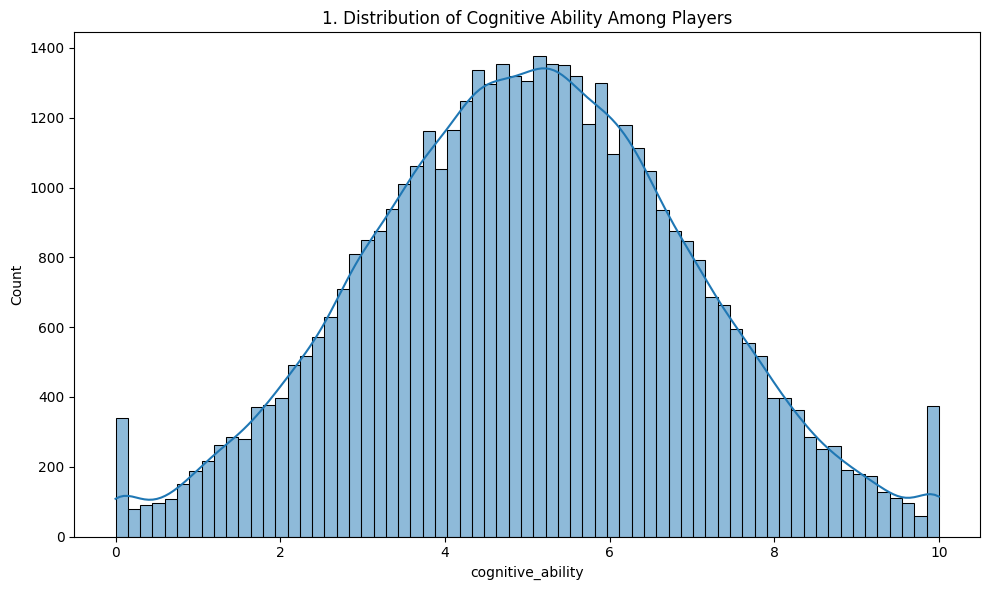

In [13]:
fig = plt.figure(figsize=(10,6))
sns.histplot(data=df, x='cognitive_ability', kde=True)
plt.title(f'{plot_no}. Distribution of Cognitive Ability Among Players')
show_fig()
plot_no += 1

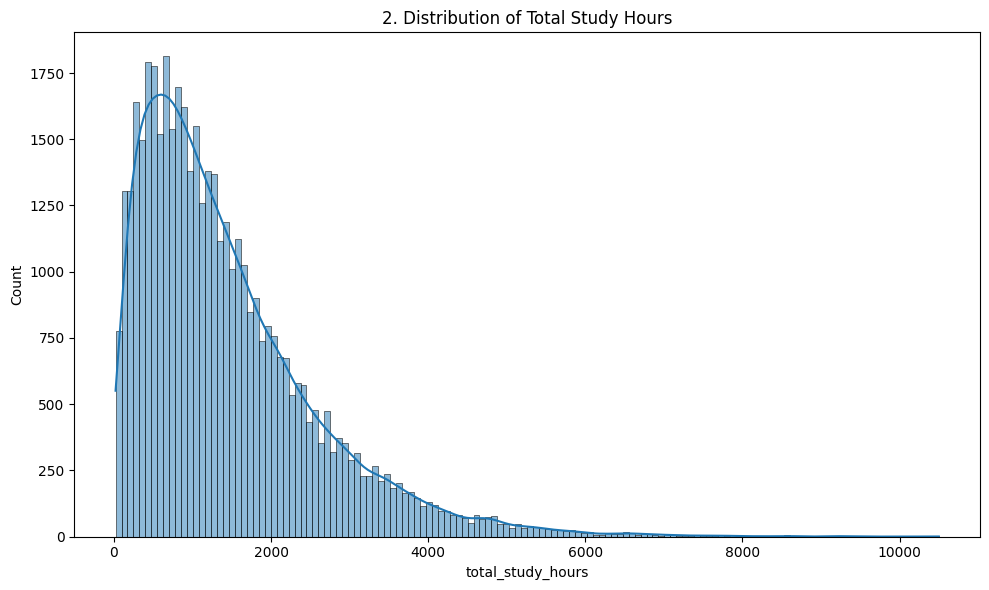

In [14]:
fig = plt.figure(figsize=(10,6))
sns.histplot(data=df, x='total_study_hours', kde=True)
plt.title(f'{plot_no}. Distribution of Total Study Hours')
show_fig()
plot_no += 1

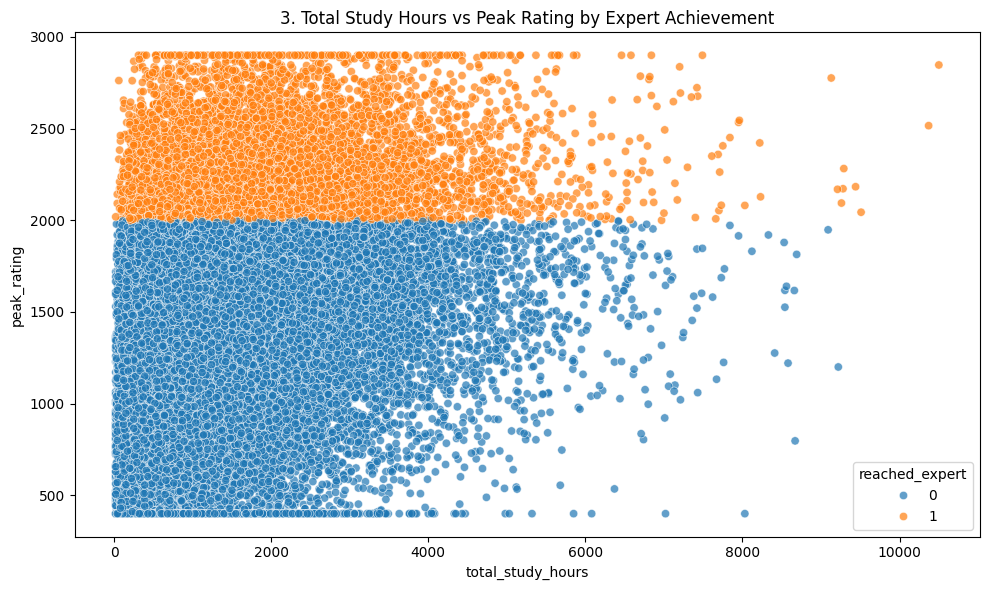

In [15]:
fig = plt.figure(figsize=(10,6))
sns.scatterplot(data=df, x='total_study_hours', y='peak_rating', hue='reached_expert', alpha=0.7)
plt.title(f'{plot_no}. Total Study Hours vs Peak Rating by Expert Achievement')
show_fig()
plot_no += 1

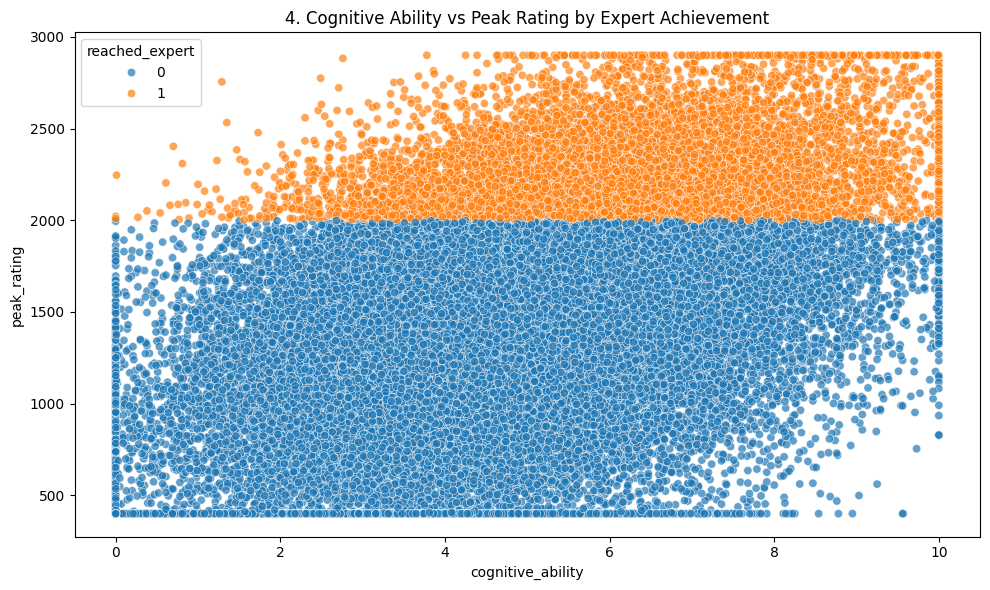

In [16]:
fig = plt.figure(figsize=(10,6))
sns.scatterplot(data=df, x='cognitive_ability', y='peak_rating', hue='reached_expert', alpha=0.7)
plt.title(f'{plot_no}. Cognitive Ability vs Peak Rating by Expert Achievement')
show_fig()
plot_no += 1

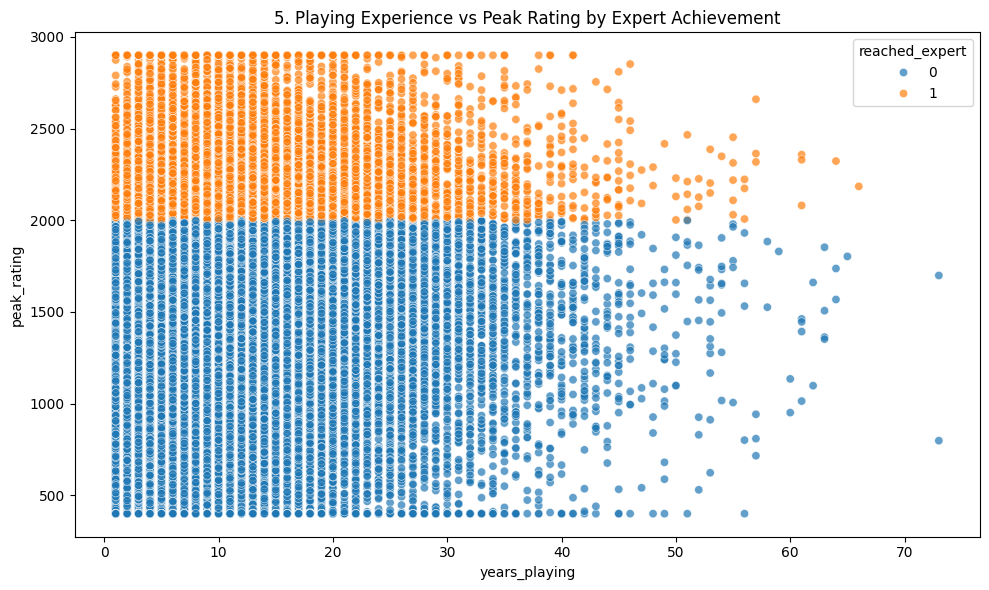

In [17]:
fig = plt.figure(figsize=(10,6))
sns.scatterplot(data=df, x='years_playing', y='peak_rating', hue='reached_expert', alpha=0.7)
plt.title(f'{plot_no}. Playing Experience vs Peak Rating by Expert Achievement')
show_fig()
plot_no += 1

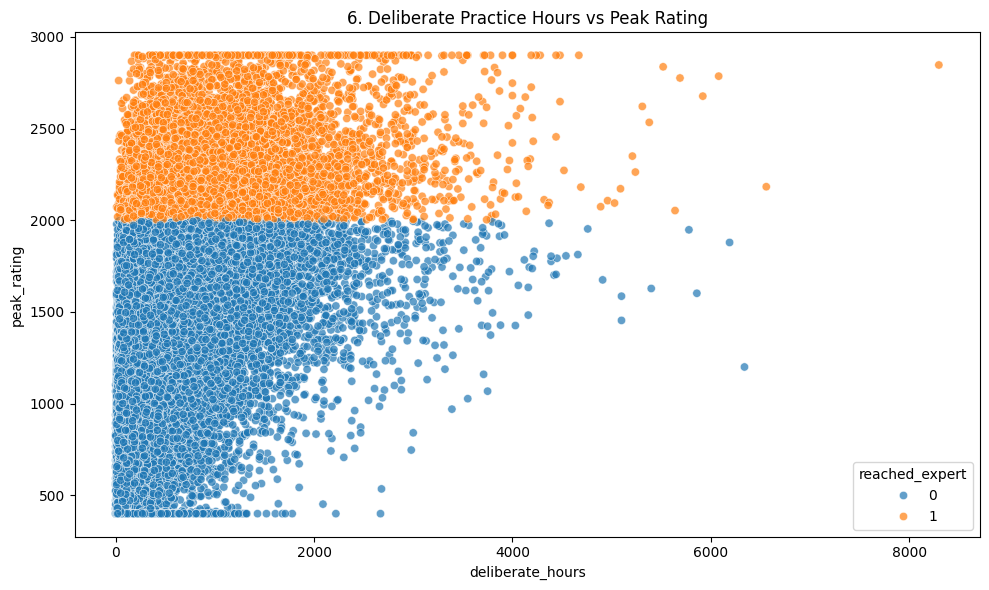

In [18]:
fig = plt.figure(figsize=(10,6))
sns.scatterplot(data=df, x='deliberate_hours', y='peak_rating', hue='reached_expert', alpha=0.7)
plt.title(f'{plot_no}. Deliberate Practice Hours vs Peak Rating')
show_fig()
plot_no += 1

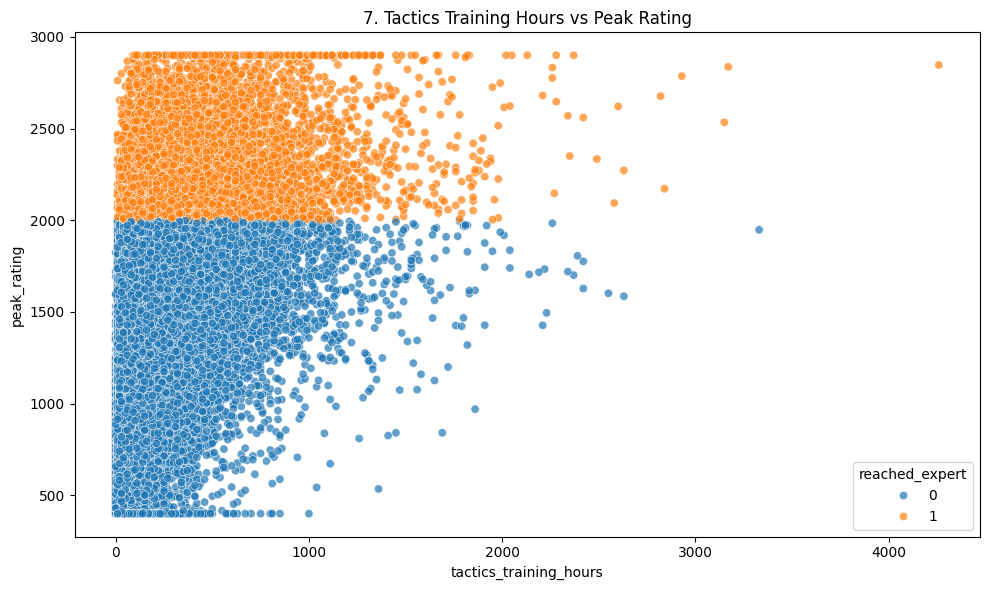

In [19]:
fig = plt.figure(figsize=(10,6))
sns.scatterplot(data=df, x='tactics_training_hours', y='peak_rating', hue='reached_expert', alpha=0.7)
plt.title(f'{plot_no}. Tactics Training Hours vs Peak Rating')
show_fig()
plot_no += 1

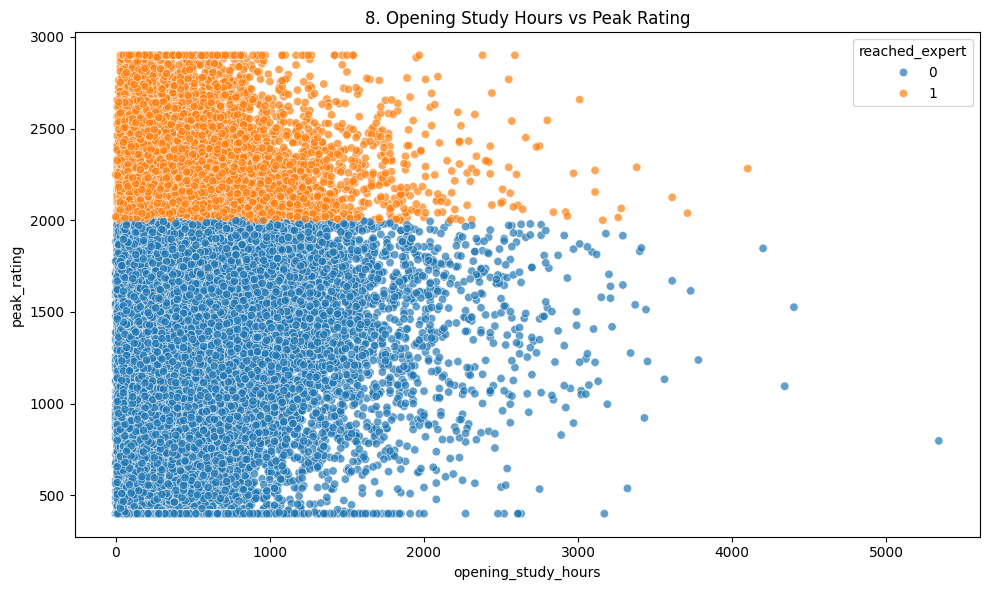

In [20]:
fig = plt.figure(figsize=(10,6))
sns.scatterplot(data=df, x='opening_study_hours', y='peak_rating', hue='reached_expert', alpha=0.7)
plt.title(f'{plot_no}. Opening Study Hours vs Peak Rating')
show_fig()
plot_no += 1

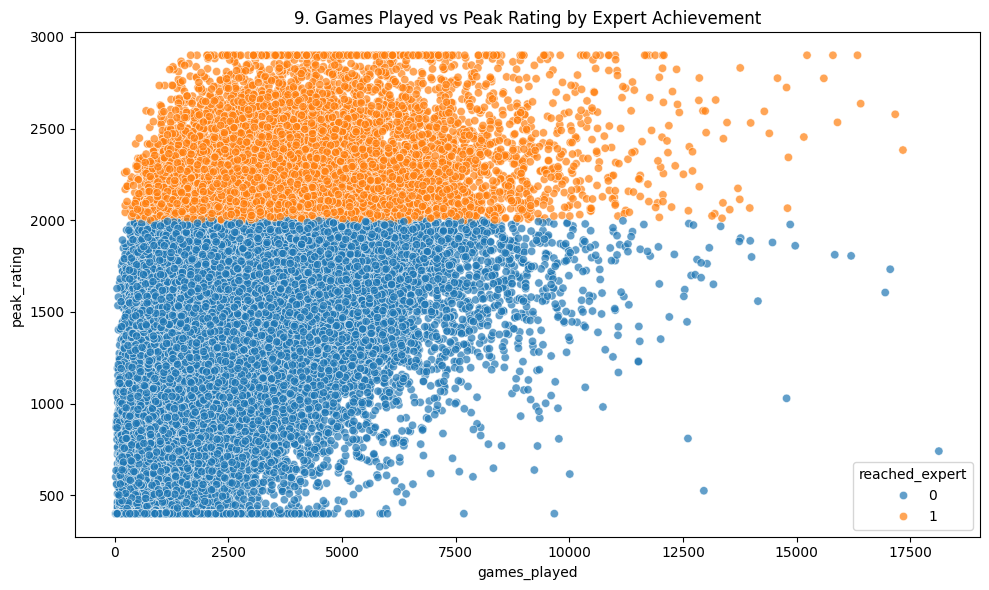

In [21]:
fig = plt.figure(figsize=(10,6))
sns.scatterplot(data=df, x='games_played', y='peak_rating', hue='reached_expert', alpha=0.7)
plt.title(f'{plot_no}. Games Played vs Peak Rating by Expert Achievement')
show_fig()
plot_no += 1

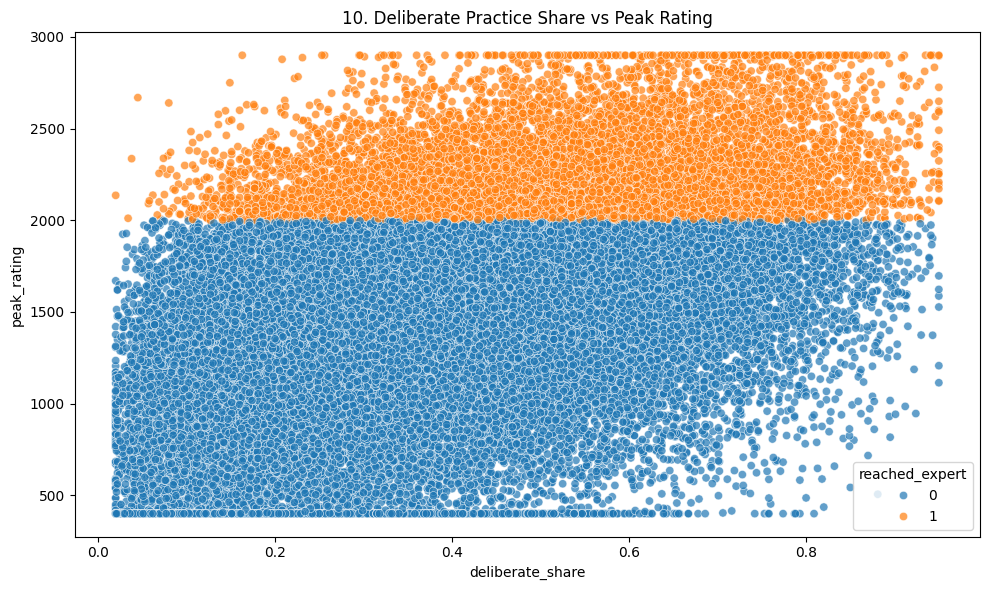

In [22]:
fig = plt.figure(figsize=(10,6))
sns.scatterplot(data=df, x='deliberate_share', y='peak_rating', hue='reached_expert', alpha=0.7)
plt.title(f'{plot_no}. Deliberate Practice Share vs Peak Rating')
show_fig()
plot_no += 1

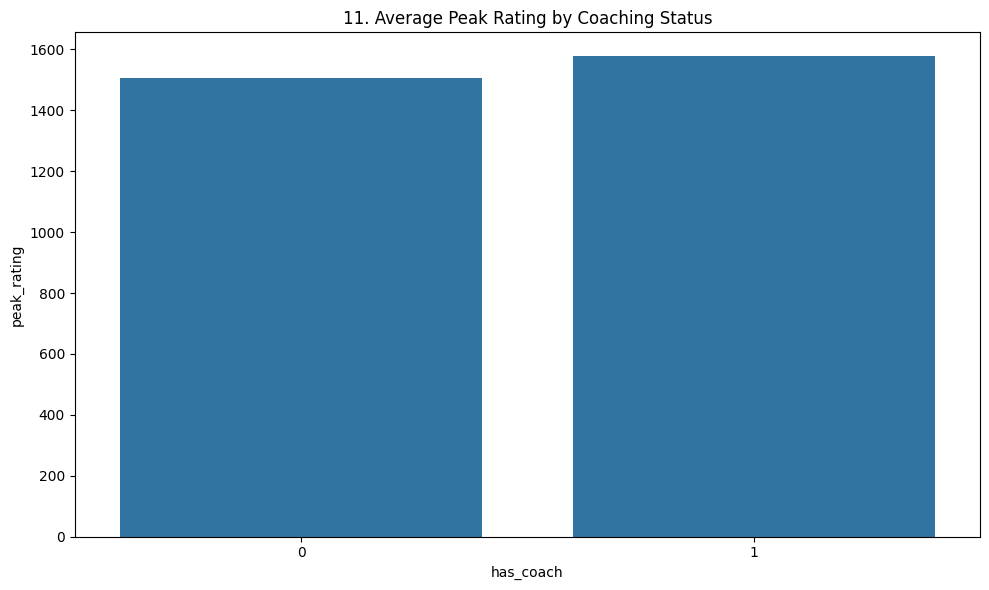

In [23]:
fig = plt.figure(figsize=(10,6))
sns.barplot(data=df, x='has_coach', y='peak_rating', errorbar=None)
plt.title(f'{plot_no}. Average Peak Rating by Coaching Status')
show_fig()
plot_no += 1

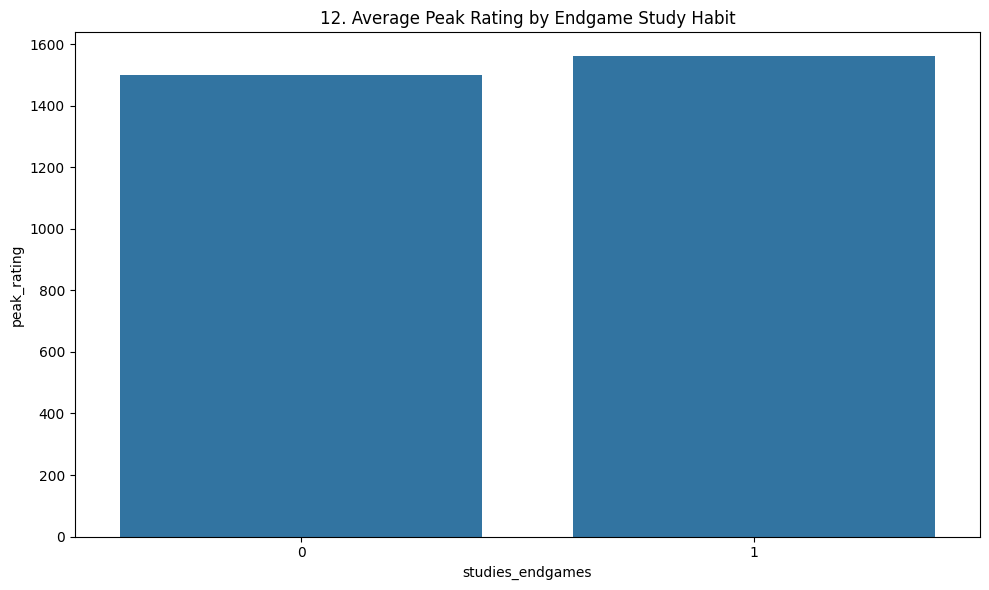

In [24]:
fig = plt.figure(figsize=(10,6))
sns.barplot(data=df, x='studies_endgames', y='peak_rating', errorbar=None)
plt.title(f'{plot_no}. Average Peak Rating by Endgame Study Habit')
show_fig()
plot_no += 1

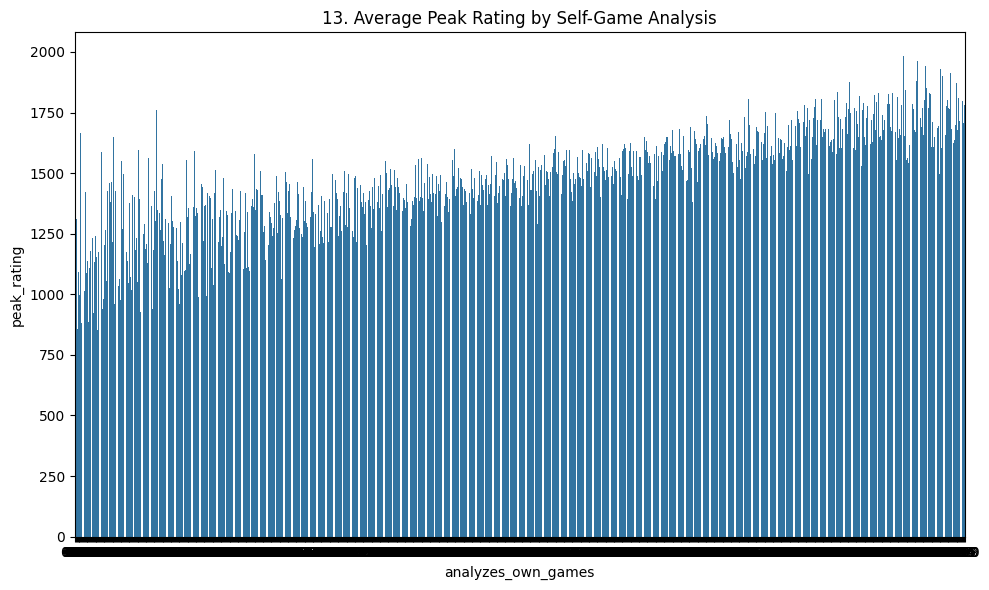

In [25]:
fig = plt.figure(figsize=(10,6))
sns.barplot(data=df, x='analyzes_own_games', y='peak_rating', errorbar=None)
plt.title(f'{plot_no}. Average Peak Rating by Self-Game Analysis')
show_fig()
plot_no += 1

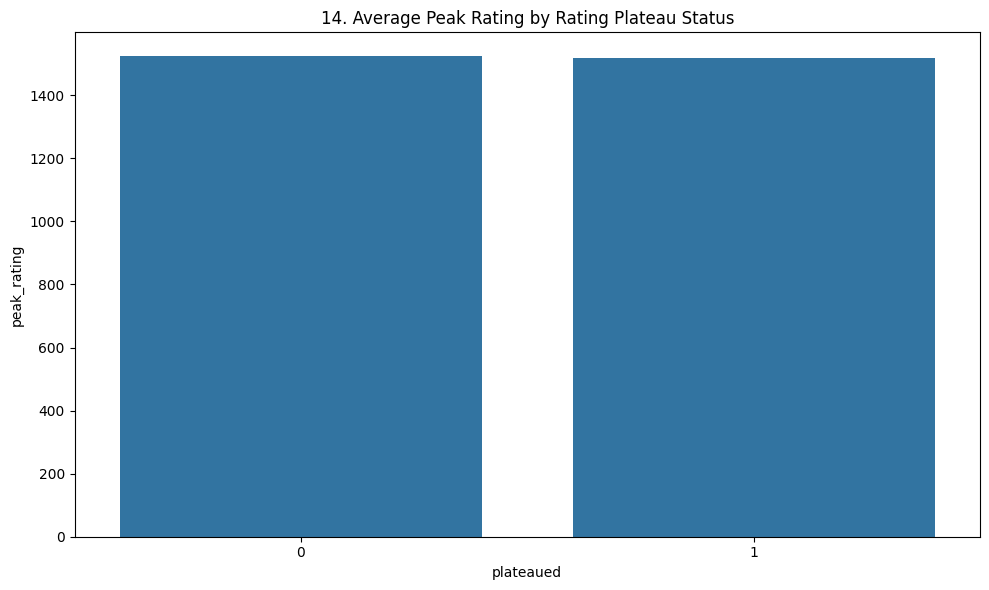

In [26]:
fig = plt.figure(figsize=(10,6))
sns.barplot(data=df, x='plateaued', y='peak_rating', errorbar=None)
plt.title(f'{plot_no}. Average Peak Rating by Rating Plateau Status')
show_fig()
plot_no += 1

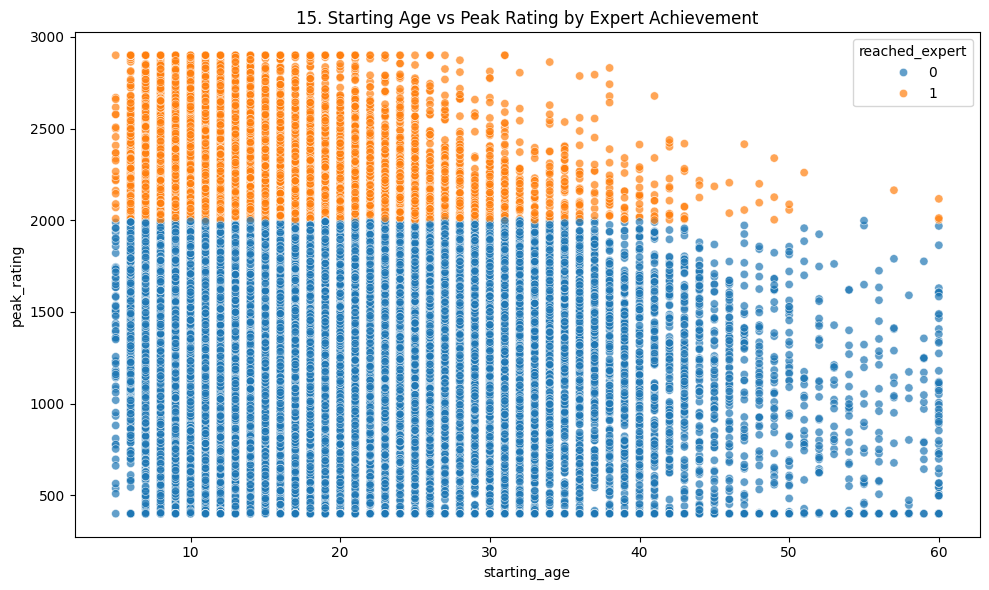

In [27]:
fig = plt.figure(figsize=(10,6))
sns.scatterplot(data=df, x='starting_age', y='peak_rating', hue='reached_expert', alpha=0.7)
plt.title(f'{plot_no}. Starting Age vs Peak Rating by Expert Achievement')
show_fig()
plot_no += 1

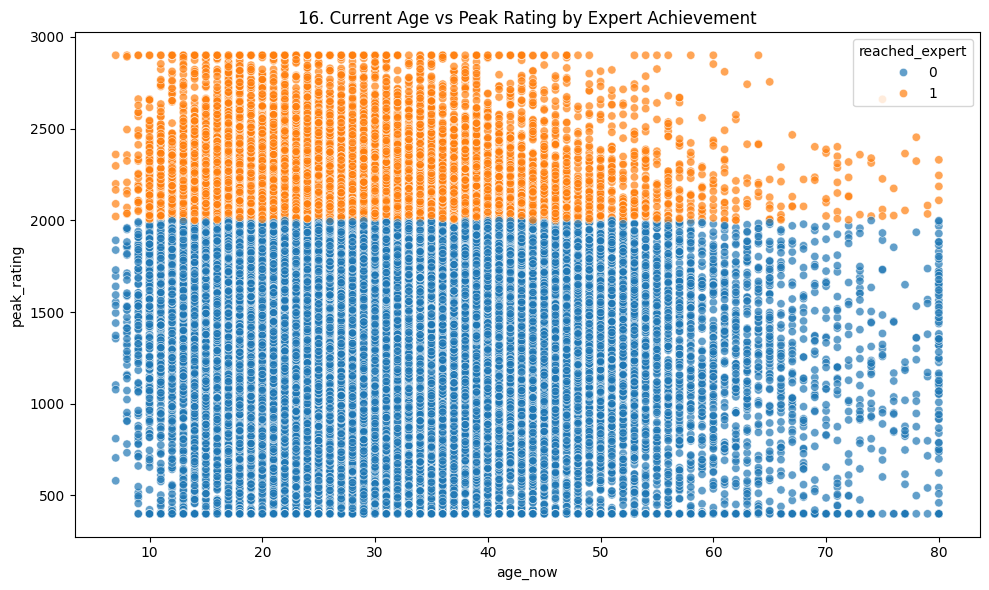

In [28]:
fig = plt.figure(figsize=(10,6))
sns.scatterplot(data=df, x='age_now', y='peak_rating', hue='reached_expert', alpha=0.7)
plt.title(f'{plot_no}. Current Age vs Peak Rating by Expert Achievement')
show_fig()
plot_no += 1

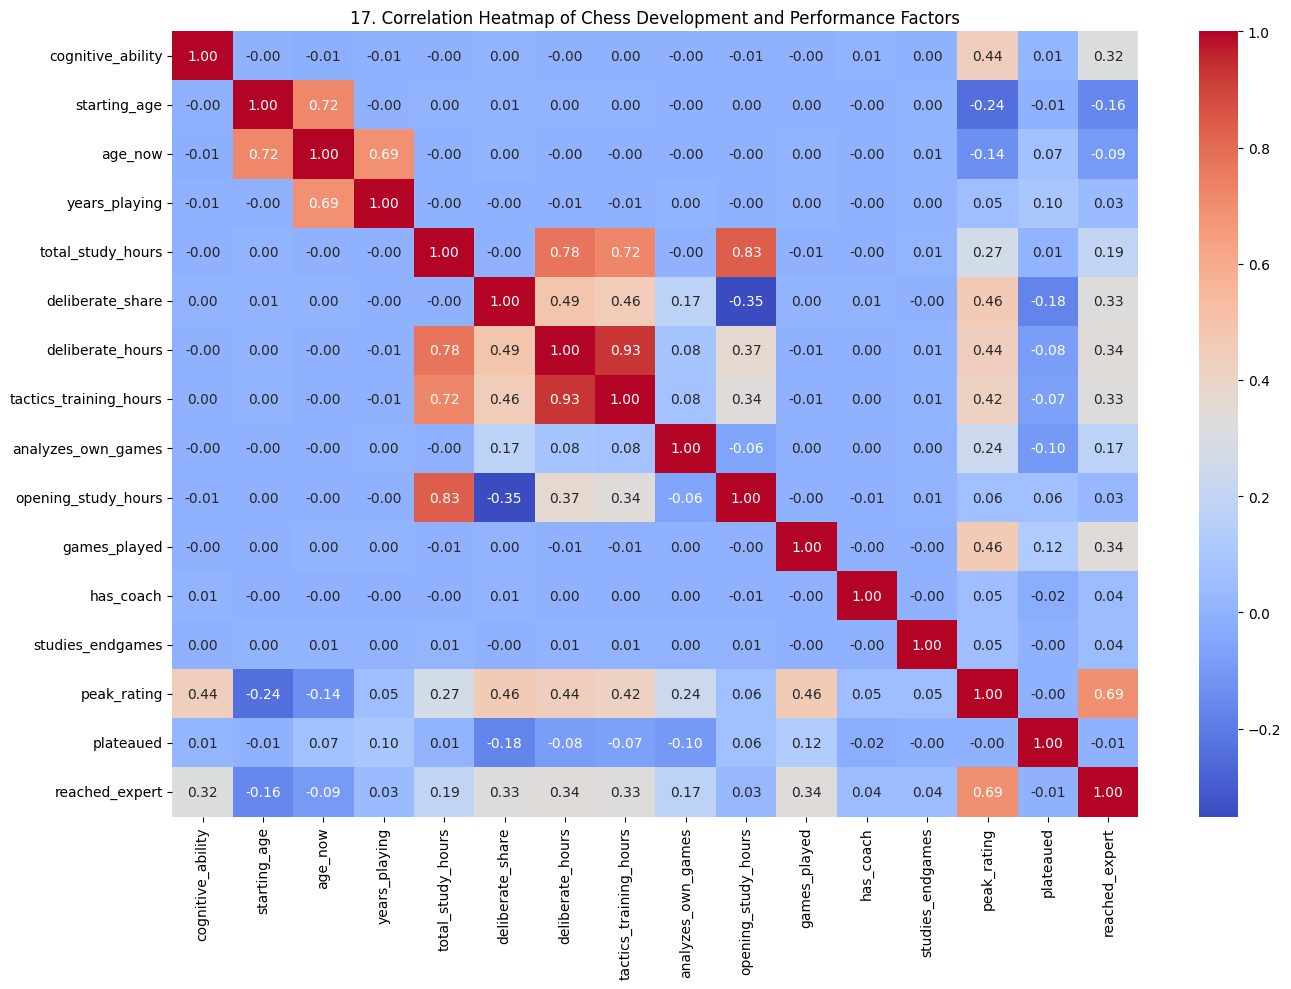

In [29]:
corr = df.select_dtypes(include='number').corr()
fig = plt.figure(figsize=(14,10))
sns.heatmap(corr, annot=True, cmap='coolwarm', fmt='.2f')
plt.title(f'{plot_no}. Correlation Heatmap of Chess Development and Performance Factors')
show_fig()
plot_no += 1

# Model Training

## Select features and target

In [30]:
X = df.drop(columns=['player_id', 'reached_expert'])
y = df['reached_expert']

## Split data

In [31]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

## Build and train model

In [32]:
model = Pipeline([
    ('scaler', StandardScaler()),
    ('classifier', LogisticRegression(max_iter=2000, class_weight='balanced'))
])
model.fit(X_train, y_train)

,steps,"[('scaler', ...), ('classifier', ...)]"
,transform_input,None
,memory,None
,verbose,False
,copy,True
,with_mean,True
,with_std,True
,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0


## Make predictions

In [33]:
y_pred = model.predict(X_test)

## Print accuracy

In [34]:
accuracy = accuracy_score(y_test, y_pred)
print(f"Model Accuracy: {accuracy:.2%}")

Model Accuracy: 99.11%


## Print classification report

In [35]:
print("\nClassification Report:")
print(classification_report(y_test, y_pred))


Classification Report:
              precision    recall  f1-score   support

           0       1.00      0.99      0.99      7200
           1       0.96      1.00      0.98      1800

    accuracy                           0.99      9000
   macro avg       0.98      0.99      0.99      9000
weighted avg       0.99      0.99      0.99      9000



## Plot confusion matrix

<Figure size 1000x600 with 0 Axes>

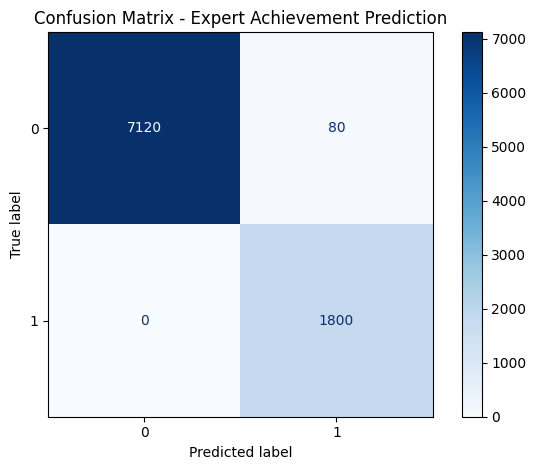

In [36]:
fig = plt.figure(figsize=(10,6))
ConfusionMatrixDisplay.from_predictions(y_test, y_pred, cmap='Blues')
plt.title('Confusion Matrix - Expert Achievement Prediction')
show_fig()
plot_no += 1